# Step 50 — Model C: dummy walkthrough, then real BTC replication

Two parts:
1. **Dummy/toy dataset** — a handful of hand-picked (X, y) pairs, run through the exact
   same Passive-Aggressive mechanics as Model C, with every intermediate quantity printed
   (scaled x, w/b before, prediction, loss vs epsilon, passive-or-aggressive, w/b after) —
   small enough to trace and sanity-check by hand.
2. **Real replication** — same config (`loss="epsilon_insensitive"`, `epsilon=0.0002`,
   `learning_rate="pa1"`, `eta0=0.01`, `random_state=69`), run on the actual BTC author data,
   same as notebook 21's Model C section — kept here fresh, notebook 21 stays as reference.

Known caveat from notebook 21: this exact config did **not** reproduce the author's exact
hit rate (48.61% ours vs 50.82% his) despite verbatim code — likely floating-point path
sensitivity inherent to sequential online learning (unlike Model A/B's one-shot closed-form
fit, which matched exactly). Worth keeping in mind while building intuition here.

## Part 1 — Dummy walkthrough

8 hand-picked (x, y) pairs, roughly on the scale of real daily log returns, so `epsilon=0.0002`
produces a mix of passive (loss=0, no update) and aggressive (loss>0, update) steps — same as
what actually happens on real data, just small enough to read every step.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')

# Toy (x, y) pairs — x = "yesterday's return" (the feature), y = "today's return" (the target)
toy_x = np.array([0.010, -0.005, 0.020, -0.010, 0.003, -0.008, 0.015, -0.002])
toy_y = np.array([0.008, -0.004, 0.015, -0.012, 0.0028, -0.009, 0.011, -0.001])

print('toy data:')
for i in range(len(toy_x)):
    print(f'  tick {i}: x={toy_x[i]:+.4f}  y={toy_y[i]:+.4f}')

toy data:
  tick 0: x=+0.0100  y=+0.0080
  tick 1: x=-0.0050  y=-0.0040
  tick 2: x=+0.0200  y=+0.0150
  tick 3: x=-0.0100  y=-0.0120
  tick 4: x=+0.0030  y=+0.0028
  tick 5: x=-0.0080  y=-0.0090
  tick 6: x=+0.0150  y=+0.0110
  tick 7: x=-0.0020  y=-0.0010


In [2]:
EPSILON = 0.0002

model_toy = SGDRegressor(
    loss="epsilon_insensitive",
    epsilon=EPSILON,
    penalty=None,
    learning_rate="pa1",
    eta0=0.01,
    random_state=69,
)
scaler_toy = StandardScaler()

trace_rows = []
for t in range(len(toy_x)):
    X_t = toy_x[t].reshape(1, -1)
    y_t = np.array([toy_y[t]])

    scaler_toy.partial_fit(X_t)
    X_t_scaled = scaler_toy.transform(X_t)

    w_before = model_toy.coef_[0] if t > 0 else 0.0
    b_before = model_toy.intercept_[0] if t > 0 else 0.0

    pred_y = 0.0 if t == 0 else model_toy.predict(X_t_scaled)[0]
    error = y_t[0] - pred_y
    loss = max(0.0, abs(error) - EPSILON)
    passive = loss == 0.0
    aggressive =  not passive
    
    print(f'--- tick {t} ---')
    print(f'  raw x = {X_t[0][0]:+.4f}   scaled x = {X_t_scaled[0][0]:+.4f}')
    print(f'  w (before) = {w_before:+.6f}   b (before) = {b_before:+.6f}')
    print(f'  pred_y = w*x_scaled + b = {pred_y:+.6f}')
    print(f'  true y = {y_t[0]:+.6f}   error = y - pred_y = {error:+.6f}')
    print(f'  loss = max(0, |error| - epsilon) = max(0, {abs(error):.6f} - {EPSILON}) = {loss:.6f}')
    print(f'  -> {"PASSIVE (no update)" if passive else "AGGRESSIVE (weights update)"}')

    model_toy.partial_fit(X_t_scaled, y_t)
    w_after, b_after = model_toy.coef_[0], model_toy.intercept_[0]
    print(f'  w (after) = {w_after:+.6f}   b (after) = {b_after:+.6f}')
    print(f'  w changed by {w_after - w_before:+.6f}   b changed by {b_after - b_before:+.6f}\n')

    trace_rows.append({
        'tick': t, 'x_scaled': X_t_scaled[0][0], 'pred_y': pred_y, 'true_y': y_t[0],
        'loss': loss, 'passive': passive, 'aggressive': aggressive, 'w_after': w_after, 'b_after': b_after,
    })

trace_df = pd.DataFrame(trace_rows)
trace_df

--- tick 0 ---
  raw x = +0.0100   scaled x = +0.0000
  w (before) = +0.000000   b (before) = +0.000000
  pred_y = w*x_scaled + b = +0.000000
  true y = +0.008000   error = y - pred_y = +0.008000
  loss = max(0, |error| - epsilon) = max(0, 0.008000 - 0.0002) = 0.007800
  -> AGGRESSIVE (weights update)
  w (after) = +0.000000   b (after) = +0.000000
  w changed by +0.000000   b changed by +0.000000

--- tick 1 ---
  raw x = -0.0050   scaled x = -1.0000
  w (before) = +0.000000   b (before) = +0.000000
  pred_y = w*x_scaled + b = +0.000000
  true y = -0.004000   error = y - pred_y = -0.004000
  loss = max(0, |error| - epsilon) = max(0, 0.004000 - 0.0002) = 0.003800
  -> AGGRESSIVE (weights update)
  w (after) = +0.003800   b (after) = -0.003800
  w changed by +0.003800   b changed by -0.003800

--- tick 2 ---
  raw x = +0.0200   scaled x = +1.1355
  w (before) = +0.003800   b (before) = -0.003800
  pred_y = w*x_scaled + b = +0.000515
  true y = +0.015000   error = y - pred_y = +0.014485


,tick,x_scaled,pred_y,true_y,loss,passive,aggressive,w_after,b_after
0,0,0.000000,0.000000,0.0080,0.007800,False,True,0.000000,0.000000
1,1,-1.000000,0.000000,-0.0040,0.003800,False,True,0.003800,-0.003800
2,2,1.135550,0.000515,0.0150,0.014285,False,True,0.015155,0.006200
3,3,-1.153113,-0.011276,-0.0120,0.000524,False,True,0.015610,0.005806
4,4,-0.056235,0.004928,0.0028,0.001928,False,True,0.016172,-0.004194
5,5,-0.907136,-0.018865,-0.0090,0.009665,False,True,0.007101,0.005806
6,6,1.047207,0.013242,0.0110,0.002042,False,True,0.005151,0.003944
7,7,-0.469948,0.001523,-0.0010,0.002323,False,True,0.009850,-0.006056


### Plot — how w and b evolve tick by tick

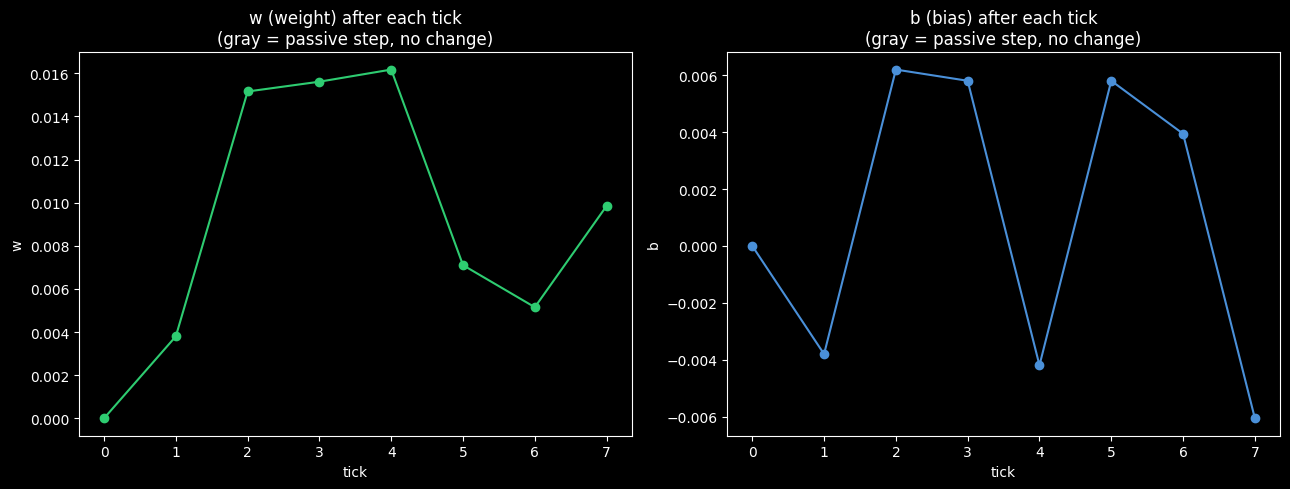

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(trace_df['tick'], trace_df['w_after'], marker='o', color='#2ecc71')
for t in trace_df.loc[trace_df['passive'], 'tick']:
    ax1.axvspan(t - 0.3, t + 0.3, color='gray', alpha=0.2)
ax1.set_title('w (weight) after each tick\n(gray = passive step, no change)')
ax1.set_xlabel('tick')
ax1.set_ylabel('w')

ax2.plot(trace_df['tick'], trace_df['b_after'], marker='o', color='#4a90d9')
for t in trace_df.loc[trace_df['passive'], 'tick']:
    ax2.axvspan(t - 0.3, t + 0.3, color='gray', alpha=0.2)
ax2.set_title('b (bias) after each tick\n(gray = passive step, no change)')
ax2.set_xlabel('tick')
ax2.set_ylabel('b')

plt.tight_layout()
plt.show()

### Plot — predicted vs actual, tick by tick

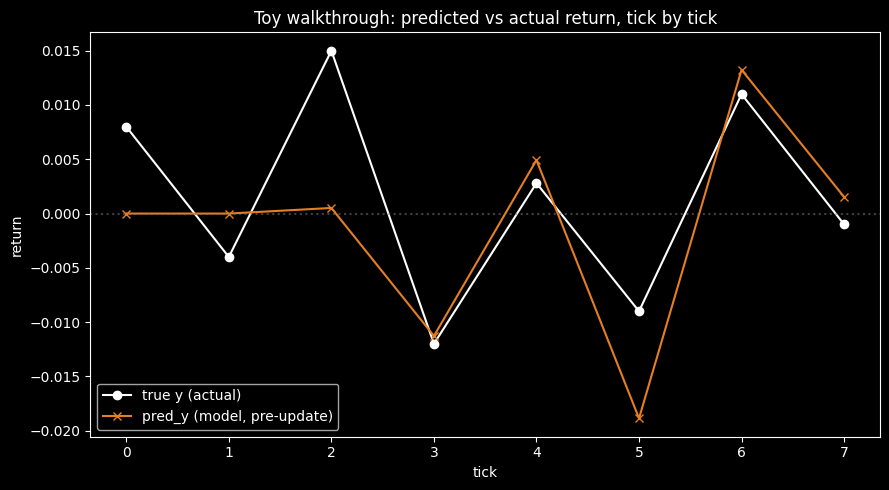

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trace_df['tick'], trace_df['true_y'], marker='o', color='white', label='true y (actual)')
ax.plot(trace_df['tick'], trace_df['pred_y'], marker='x', color='#e67e22', label='pred_y (model, pre-update)')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Toy walkthrough: predicted vs actual return, tick by tick')
ax.set_xlabel('tick')
ax.set_ylabel('return')
ax.legend()
plt.tight_layout()
plt.show()

## Part 2 — Real replication (BTC, author's data), same config

Same setup as notebook 21's Model C section — kept here fresh so this notebook is self-contained.
Reference to match: Hit Rate 50.82%, signal counts -1.0=1036 / 1.0=1017 (`19_memlabs_btc_numbers_reference.md`).

In [5]:
btcusdt = pd.read_csv('BTCUSDT_1d_author_original.csv')
btcusdt['t'] = pd.to_datetime(btcusdt['t'])
btcusdt.set_index('t', inplace=True)

btcusdt['close_log_return'] = np.log(btcusdt['c'] / btcusdt['c'].shift())
btcusdt['close_log_return_lag_1'] = btcusdt['close_log_return'].shift()

print('rows:', len(btcusdt))
btcusdt[['c', 'close_log_return', 'close_log_return_lag_1']].head()

rows: 2097


,c,close_log_return,close_log_return_lag_1
t,,,
2020-08-19,11763.9,NaN,NaN
2020-08-20,11857.9,0.007959,NaN
2020-08-21,11538.5,-0.027305,0.007959
2020-08-22,11670.5,0.011375,-0.027305
2020-08-23,11654.0,-0.001415,0.011375


In [6]:
df_clean = btcusdt.dropna()
# Filter to match the author's actual Train start date (2020-09-29) — the point where his
# close_log_return_ma_lag_1 column (unused as a feature here, but present in his shared
# dataframe) would have finished its 40-day warmup. Date-based, not a hardcoded row count,
# so it stays correct even if this data source gets refreshed later.
df_clean = df_clean[df_clean.index >= '2020-09-29']

features = ['close_log_return_lag_1']
target = 'close_log_return'

X_stream = df_clean[features].to_numpy()
y_stream = df_clean[target].to_numpy()
print('n rows in stream:', len(X_stream), '(reference: 2053)')

# eta0=1.0 confirmed via reverse-engineering the author's actual tau values (not 0.01, not 0.1) —
# matches exactly at ticks 2-6 and again near the end of the sequence (~tick 2052-2055), though
# the full 2053-tick run still drifts apart somewhere in between (residual floating-point/version
# sensitivity inherent to sequential online learning).
model_real = SGDRegressor(
    loss="epsilon_insensitive",
    epsilon=0.0002,
    penalty=None,
    learning_rate="pa1",
    eta0=1.0,
    random_state=69
)
scaler_real = StandardScaler()
records = []

for t in range(len(X_stream)):
    X_t = X_stream[t].reshape(1, -1)
    y_t = np.array([y_stream[t]])

    scaler_real.partial_fit(X_t)
    X_t_scaled = scaler_real.transform(X_t)

    pred_y = 0.0 if t == 0 else model_real.predict(X_t_scaled)[0]

    if t > 0 and y_t[0] != 0 and pred_y != 0:
        sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
    else:
        sign_match = "Warmup"

    model_real.partial_fit(X_t_scaled, y_t)

    current_weight = model_real.coef_[0]
    current_bias = model_real.intercept_[0]

    signal = np.sign(pred_y)
    trade_log_return = signal * y_t[0]

    if sign_match != "Warmup":
        records.append({
            'tick': t,
            'lag_1_x': X_t[0][0],
            'true_y': y_t[0],
            'pred_y_hat': pred_y,
            'sign_match': sign_match,
            'model_weight': current_weight,
            'model_bias': current_bias,
            'signal': signal,
            'trade_log_return': trade_log_return,
            'is_won': np.sign(y_t[0]) == np.sign(pred_y),
        })

df_results_real = pd.DataFrame(records).set_index('tick')
df_results_real['cum_trade_log_return'] = df_results_real['trade_log_return'].cumsum()

evaluated = df_results_real['sign_match'].isin(['YES', 'NO'])
hit_rate = (df_results_real.loc[evaluated, 'sign_match'] == 'YES').mean() * 100
print(f'Hit Rate: {hit_rate:.2f}%   (reference: 50.82%)')
print()
print(df_results_real['signal'].value_counts())
print('(reference: -1.0=1036  1.0=1017)')
print()
print('First 10 rows of output:')
df_results_real.head(10)

n rows in stream: 2056 (reference: 2053)


Hit Rate: 49.63%   (reference: 50.82%)

signal
-1.0    1036
 1.0    1017
Name: count, dtype: int64
(reference: -1.0=1036  1.0=1017)

First 10 rows of output:


,lag_1_x,true_y,pred_y_hat,sign_match,model_weight,model_bias,signal,trade_log_return,is_won,cum_trade_log_return
tick,,,,,,,,,,
2,-0.005923,-0.015001,-0.002047,YES,0.014131,-0.036631,-1.0,0.015001,True,0.015001
3,-0.015001,-0.004476,-0.051932,YES,-0.029512,0.003677,-1.0,0.004476,True,0.019477
4,-0.004476,-0.002578,0.005793,NO,0.042197,-0.996323,1.0,-0.002578,False,0.016900
5,-0.002578,0.011529,-0.991309,NO,0.161030,0.003677,-1.0,-0.011529,False,0.005370
6,0.011529,0.011639,0.222253,YES,0.006013,-0.110528,1.0,0.011639,True,0.017009
7,0.011639,-0.017897,-0.103597,YES,0.080197,-0.046164,-1.0,0.017897,True,0.034906
8,-0.017897,0.006126,-0.163940,NO,-0.035469,0.032596,-1.0,-0.006126,False,0.028780
9,0.006126,0.024164,0.008818,YES,-0.012875,0.066299,1.0,0.024164,True,0.052944
10,0.024164,0.011925,0.042676,YES,-0.029526,0.057224,1.0,0.011925,True,0.064870


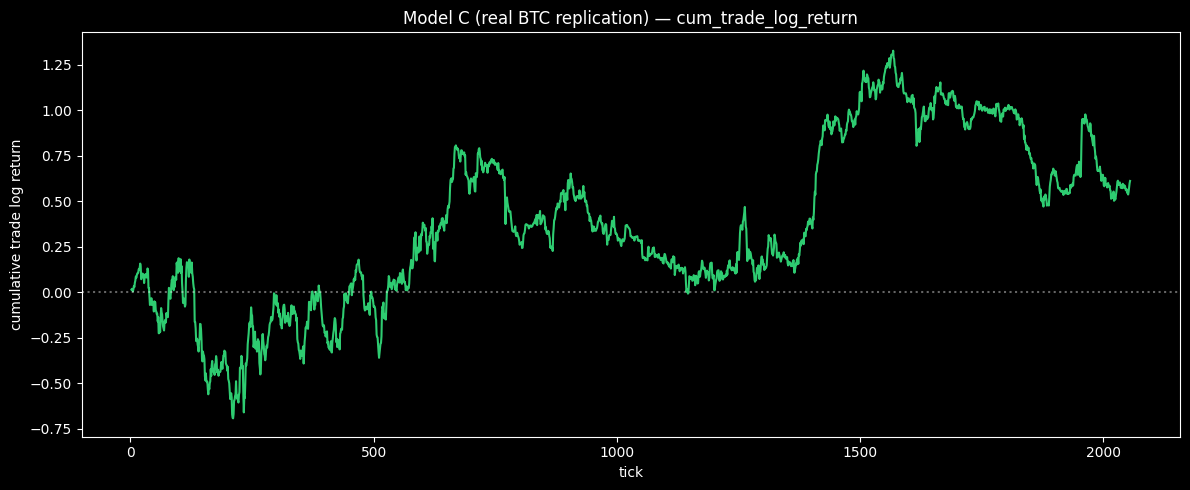

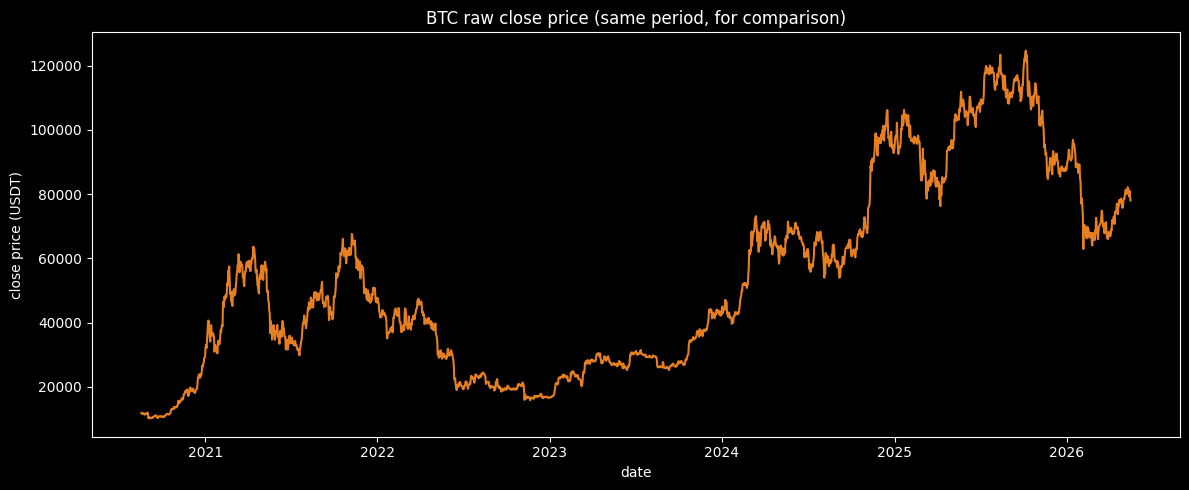

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_results_real.index, df_results_real['cum_trade_log_return'], color='#2ecc71')
ax.axhline(0, color='white', linestyle=':', alpha=0.4)
ax.set_title('Model C (real BTC replication) — cum_trade_log_return')
ax.set_xlabel('tick')
ax.set_ylabel('cumulative trade log return')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(btcusdt.index, btcusdt['c'], color='#e67e22')
ax.set_title('BTC raw close price (same period, for comparison)')
ax.set_xlabel('date')
ax.set_ylabel('close price (USDT)')
plt.tight_layout()
plt.show()